# EDA Part 1: Intro

 > ### 1. Import libraries & loading dataset

In [2]:
# Importing libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from datasets import load_dataset
from adjustText import adjust_text

In [3]:
# Loading dataset
raw = load_dataset('lukebarousse/data_jobs')

In [4]:
raw

DatasetDict({
    train: Dataset({
        features: ['job_title_short', 'job_title', 'job_location', 'job_via', 'job_schedule_type', 'job_work_from_home', 'search_location', 'job_posted_date', 'job_no_degree_mention', 'job_health_insurance', 'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg', 'company_name', 'job_skills', 'job_type_skills'],
        num_rows: 785741
    })
})

In [5]:
# transform the datasets into dataframe and using copy() method to copy the records, in order to keep the original dataset safe.
df = raw['train'].to_pandas().copy()
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


>#### 1.2 Data Cleaning

In [6]:
# Converting data type from object to datetime 
df['job_posted_date']= pd.to_datetime(df.job_posted_date)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [7]:
# Convert stringified list values in 'job_skills' back into actual Python lists (skip NaNs)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x )
df['job_skills']

0                                                       NaN
1                [r, python, sql, nosql, power bi, tableau]
2         [python, sql, c#, azure, airflow, dax, docker,...
3         [python, c++, java, matlab, aws, tensorflow, k...
4         [bash, python, oracle, aws, ansible, puppet, j...
                                ...                        
785736    [bash, python, perl, linux, unix, kubernetes, ...
785737                               [sas, sas, sql, excel]
785738                                  [powerpoint, excel]
785739    [python, go, nosql, sql, mongo, shell, mysql, ...
785740                                          [aws, flow]
Name: job_skills, Length: 785741, dtype: object

> ## 1. How does job posting activity change throughout the year?

In [8]:
df['job_posted_month'] = df['job_posted_date'].dt.month

In [9]:
jobs_month = df['job_posted_month'].value_counts().sort_index().reset_index(name='Job_count')


In [10]:
jobs_month['job_Month'] = jobs_month['job_posted_month'].apply(lambda x: pd.to_datetime(x,format='%m').strftime('%b'))
jobs_month.set_index('job_Month')
jobs_month.drop(labels='job_posted_month',axis=1,inplace=True)
jobs_month


,Job_count,job_Month
0,91822,Jan
1,64578,Feb
2,64084,Mar
3,62919,Apr
4,52104,May
5,61572,Jun
6,63777,Jul
7,75162,Aug
8,62359,Sep
9,66611,Oct


In [11]:
jobs_month.set_index('job_Month',inplace=True)
jobs_month

,Job_count
job_Month,
Jan,91822
Feb,64578
Mar,64084
Apr,62919
May,52104
Jun,61572
Jul,63777
Aug,75162
Sep,62359


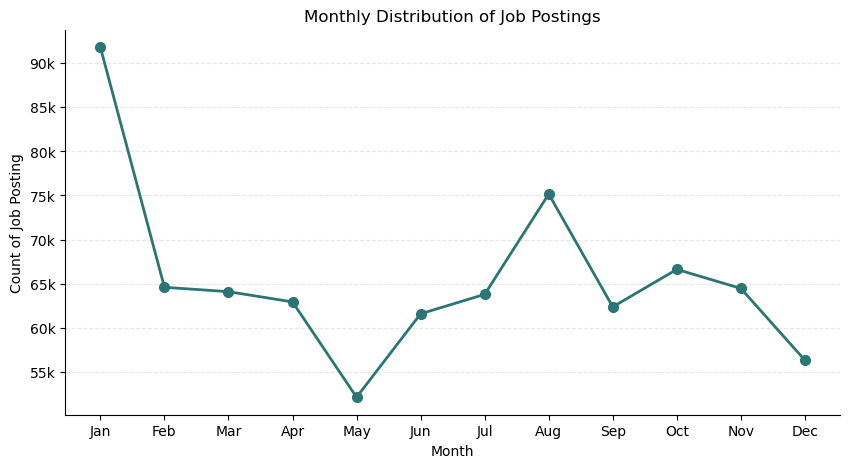

In [12]:
ax= jobs_month.plot(kind='line',linewidth= 2,marker='o', markersize='7',color='#2b7574',figsize=(10,5))

plt.title('Monthly Distribution of Job Postings')
plt.xlabel('Month')
plt.ylabel('Count of Job Posting')
plt.legend().remove()
plt.grid(axis='y',
         linestyle='--',
         alpha=0.3)

axis = plt.gca()
axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos : f'{int(y/1000)}k'))

ax.set_xticks(range(len(jobs_month.index)))
ax.set_xticklabels(jobs_month.index)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

> ## 2. Which job roles have the highest number of job postings?

In [13]:
Roles =df['job_title_short'].value_counts().to_frame()
Roles

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


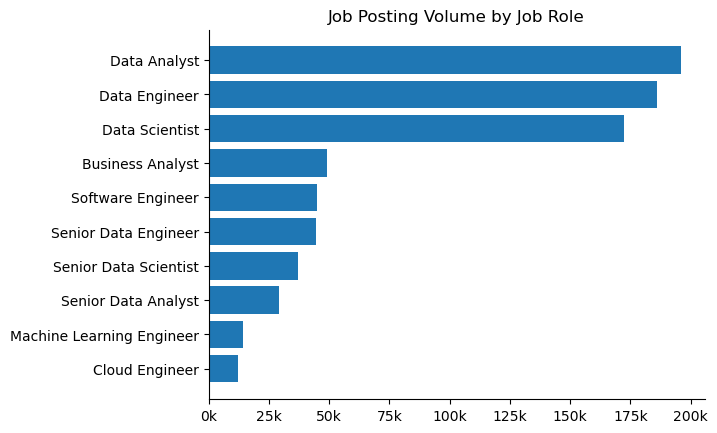

In [14]:
plt.barh(Roles.index,Roles['count'])
ax = plt.gca()
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'{int(x/1000)}k'))
plt.title('Job Posting Volume by Job Role')
sns.despine()

> ## 3. How do monthly hiring trends differ among the top five data-related job roles?

In [15]:
df_explode = df.explode('job_skills').copy()

In [16]:
df_pivot = df_explode.pivot_table(index='job_posted_month',columns='job_title_short',aggfunc='size')
df_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
1,14866,5579,81796,134082,101633,8003,15833,36325,24487,26871
2,11043,3712,57654,102217,69085,5979,11990,27482,15725,17071
3,10506,4009,56746,102630,66156,6310,10898,28023,15741,20543
4,12476,4258,54679,94042,66306,5760,9768,26041,14436,21474
5,7428,1960,47014,87098,58393,5107,8262,23761,12648,11017
6,10258,3086,55464,98348,67813,6219,9979,28203,15333,11850
7,11843,4450,55903,91001,68843,6447,9881,26556,16383,18350
8,15430,5666,64897,97350,82602,7515,11784,28356,21100,25990
9,12606,3769,50019,86597,62060,6743,8352,23706,14280,16001


In [17]:
df_pivot.reset_index(inplace=True)

In [18]:
df_pivot['job_posted_month']= df_pivot['job_posted_month'].apply(lambda x: pd.to_datetime(x,format='%m').strftime('%b'))
df_pivot.set_index('job_posted_month',inplace=True)
df_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
Jan,14866,5579,81796,134082,101633,8003,15833,36325,24487,26871
Feb,11043,3712,57654,102217,69085,5979,11990,27482,15725,17071
Mar,10506,4009,56746,102630,66156,6310,10898,28023,15741,20543
Apr,12476,4258,54679,94042,66306,5760,9768,26041,14436,21474
May,7428,1960,47014,87098,58393,5107,8262,23761,12648,11017
Jun,10258,3086,55464,98348,67813,6219,9979,28203,15333,11850
Jul,11843,4450,55903,91001,68843,6447,9881,26556,16383,18350
Aug,15430,5666,64897,97350,82602,7515,11784,28356,21100,25990
Sep,12606,3769,50019,86597,62060,6743,8352,23706,14280,16001


In [19]:
Top5=df_explode['job_title_short'].value_counts().sort_values(ascending=False).head(5).index.to_list()
Top5

['Data Engineer',
 'Data Scientist',
 'Data Analyst',
 'Senior Data Engineer',
 'Software Engineer']

In [20]:
df_pivot[Top5]

job_title_short,Data Engineer,Data Scientist,Data Analyst,Senior Data Engineer,Software Engineer
job_posted_month,,,,,
Jan,134082,101633,81796,36325,26871
Feb,102217,69085,57654,27482,17071
Mar,102630,66156,56746,28023,20543
Apr,94042,66306,54679,26041,21474
May,87098,58393,47014,23761,11017
Jun,98348,67813,55464,28203,11850
Jul,91001,68843,55903,26556,18350
Aug,97350,82602,64897,28356,25990
Sep,86597,62060,50019,23706,16001


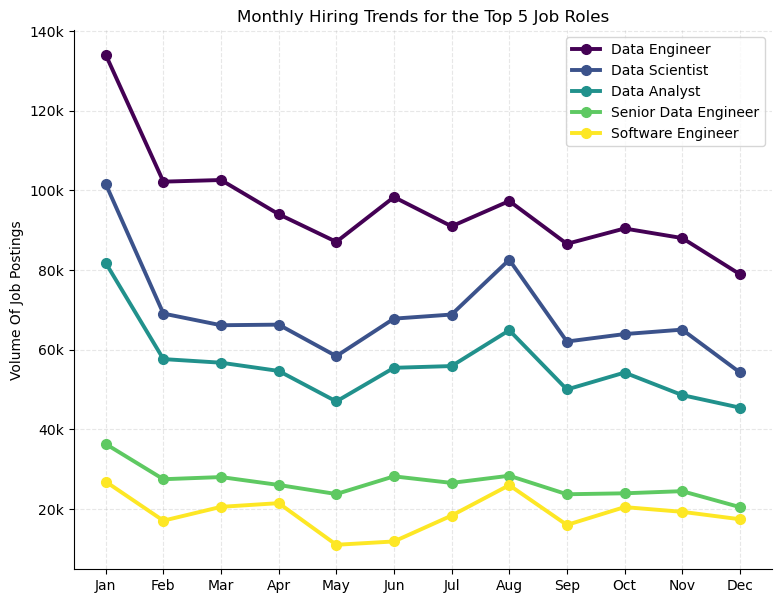

In [21]:
ax = df_pivot[Top5].plot(kind='line',figsize=(9,7),linewidth =2.8,marker='o',markersize=7,colormap='viridis')

plt.title('Monthly Hiring Trends for the Top 5 Job Roles')
plt.xlabel('')
plt.ylabel('Volume Of Job Postings')
plt.grid(axis='both',linestyle='--',alpha=0.3)
plt.legend(
    #bbox_to_anchor=(-0.1, 1),
    loc='upper right',
    frameon=True
)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'{int(y/1000)}k'))
ax.set_xticks(range(len(df_pivot.index)))
ax.set_xticklabels(df_pivot.index)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

>## 4. How does demand for the top five technical skills change throughout the year?

In [22]:
df_skill_pivot=df_explode.pivot_table(index='job_posted_month',columns='job_skills',aggfunc='size',fill_value=0)
df_skill_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,wimi,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,5136,36,1509,677,19,965,12,33,71,158,...,0,1530,62,3877,8,15,10,8,255,292
2,3709,15,1150,447,14,696,8,22,51,123,...,0,1205,32,2764,13,8,10,9,186,159
3,3876,14,1092,415,16,757,21,15,50,99,...,0,1109,30,2683,3,6,5,3,185,151
4,3805,17,1068,491,14,726,23,23,38,104,...,0,1156,44,2617,13,2,2,4,157,131
5,3480,24,857,358,7,526,12,20,28,81,...,0,780,19,2044,9,4,3,3,150,128
6,3810,31,1060,398,10,608,21,15,50,91,...,0,952,42,2557,11,11,9,2,192,145
7,3685,21,1015,406,4,634,23,13,73,104,...,0,1115,48,2373,2,3,1,5,174,142
8,4035,34,1175,554,4,761,28,25,47,142,...,0,1405,45,2945,3,3,2,7,222,172
9,3289,18,923,366,7,564,14,29,37,68,...,0,960,39,2253,2,3,14,8,169,129


In [23]:
df_skill_pivot.loc['total'] = df_skill_pivot.sum()
df_skill_pivot=df_skill_pivot[df_skill_pivot.loc['total'].sort_values(ascending=False).index]
df_skill_pivot

job_skills,sql,python,aws,azure,r,tableau,excel,spark,power bi,java,...,asp.netcore,esquisse,deno,dingtalk,gtx,msaccess,rubyon rails,rocketchat,wimi,visualbasic
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,45774,44889,16805,15385,16351,14805,15087,14304,10660,10447,...,0,0,0,0,0,0,0,1,0,0
2,32720,31943,12219,11114,11288,11008,10732,10170,8033,7507,...,0,1,1,0,0,0,1,0,0,0
3,32282,31990,12458,11152,11358,10870,10546,9994,7868,7649,...,0,0,1,0,0,0,0,0,0,0
4,31096,30482,11635,10557,10647,10430,10562,9234,7792,7294,...,0,0,0,0,0,0,0,0,0,0
5,27096,26908,10394,9111,9339,9236,8477,8278,6869,6004,...,1,0,0,0,0,1,0,0,0,0
6,31671,31216,11759,10793,10820,10575,10397,9729,8286,6886,...,0,1,0,0,0,0,0,0,0,0
7,31869,31257,12017,10960,10793,10758,10301,9085,8500,6818,...,0,0,0,0,1,0,0,0,0,0
8,36699,36228,13817,12193,13037,12497,12563,10533,9450,7937,...,2,0,0,0,0,0,0,0,0,0
9,28926,28616,10934,10221,9248,9344,9649,8383,7764,6120,...,0,0,0,0,0,0,0,0,0,0


In [24]:
df_skill_pivot.drop('total',axis=0,inplace=True)
df_skill_pivot

job_skills,sql,python,aws,azure,r,tableau,excel,spark,power bi,java,...,asp.netcore,esquisse,deno,dingtalk,gtx,msaccess,rubyon rails,rocketchat,wimi,visualbasic
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,45774,44889,16805,15385,16351,14805,15087,14304,10660,10447,...,0,0,0,0,0,0,0,1,0,0
2,32720,31943,12219,11114,11288,11008,10732,10170,8033,7507,...,0,1,1,0,0,0,1,0,0,0
3,32282,31990,12458,11152,11358,10870,10546,9994,7868,7649,...,0,0,1,0,0,0,0,0,0,0
4,31096,30482,11635,10557,10647,10430,10562,9234,7792,7294,...,0,0,0,0,0,0,0,0,0,0
5,27096,26908,10394,9111,9339,9236,8477,8278,6869,6004,...,1,0,0,0,0,1,0,0,0,0
6,31671,31216,11759,10793,10820,10575,10397,9729,8286,6886,...,0,1,0,0,0,0,0,0,0,0
7,31869,31257,12017,10960,10793,10758,10301,9085,8500,6818,...,0,0,0,0,1,0,0,0,0,0
8,36699,36228,13817,12193,13037,12497,12563,10533,9450,7937,...,2,0,0,0,0,0,0,0,0,0
9,28926,28616,10934,10221,9248,9344,9649,8383,7764,6120,...,0,0,0,0,0,0,0,0,0,0


In [25]:
df_skill_pivot.reset_index(inplace=True)
df_skill_pivot['job_posted_month'] = df_skill_pivot['job_posted_month'].apply(lambda x : pd.to_datetime(x,format='%m').strftime('%b'))
df_skill_pivot.set_index('job_posted_month',inplace=True)
df_skill_pivot

job_skills,sql,python,aws,azure,r,tableau,excel,spark,power bi,java,...,asp.netcore,esquisse,deno,dingtalk,gtx,msaccess,rubyon rails,rocketchat,wimi,visualbasic
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,45774,44889,16805,15385,16351,14805,15087,14304,10660,10447,...,0,0,0,0,0,0,0,1,0,0
Feb,32720,31943,12219,11114,11288,11008,10732,10170,8033,7507,...,0,1,1,0,0,0,1,0,0,0
Mar,32282,31990,12458,11152,11358,10870,10546,9994,7868,7649,...,0,0,1,0,0,0,0,0,0,0
Apr,31096,30482,11635,10557,10647,10430,10562,9234,7792,7294,...,0,0,0,0,0,0,0,0,0,0
May,27096,26908,10394,9111,9339,9236,8477,8278,6869,6004,...,1,0,0,0,0,1,0,0,0,0
Jun,31671,31216,11759,10793,10820,10575,10397,9729,8286,6886,...,0,1,0,0,0,0,0,0,0,0
Jul,31869,31257,12017,10960,10793,10758,10301,9085,8500,6818,...,0,0,0,0,1,0,0,0,0,0
Aug,36699,36228,13817,12193,13037,12497,12563,10533,9450,7937,...,2,0,0,0,0,0,0,0,0,0
Sep,28926,28616,10934,10221,9248,9344,9649,8383,7764,6120,...,0,0,0,0,0,0,0,0,0,0


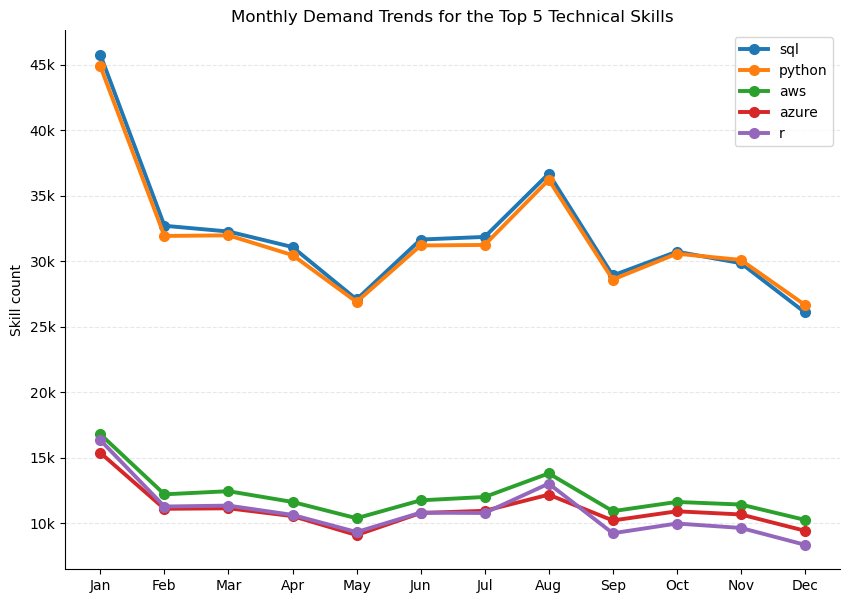

In [26]:
ax=df_skill_pivot.iloc[:,:5].plot(kind='line',linewidth=2.8,marker='o',markersize=7,figsize=(10,7))
plt.legend()
plt.title('Monthly Demand Trends for the Top 5 Technical Skills')
plt.xlabel('')
plt.ylabel('Skill count')
plt.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_xticks(range(len(df_skill_pivot.index)))
ax.set_xticklabels(df_skill_pivot.index)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos : f'{int(y/1000)}k'))
ax.spines[['top','right']].set_visible(False)
plt.show()